**Step 1 — Data Ingestion & AAMI Mapping**

In [1]:
!pip install wfdb
import torch
import os
import pickle
import numpy as np
import wfdb

print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: None (running on CPU)A")

AAMI_MAP = {
    'N':'N','L':'N','R':'N','e':'N','j':'N',
    'A':'S','a':'S','J':'S','S':'S',
    'V':'V','E':'V',
    'F':'F',
    '/':'Q','f':'Q','Q':'Q',
}

CLASS2IDX = {'N':0,'S':1,'V':2,'F':3,'Q':4}

MIT_BIH_RECORDS = [
    '100','101','102','103','104','105','106','107',
    '108','109','111','112','113','114','115','116',
    '117','118','119','121','122','123','124','200',
    '201','202','203','205','207','208','209','210',
    '212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]

def load_record(record_id, data_dir='mitdb'):
    path   = os.path.join(data_dir, record_id)
    record = wfdb.rdrecord(path)
    annot  = wfdb.rdann(path, 'atr')
    signal = record.p_signal  # (N, 2)
    fs     = record.fs
    return signal, fs, annot.sample, annot.symbol


def extract_beats(signal, fs, r_peaks, symbols, before=150, after=150):
    # FIX: empty return now has shape (0, before+after, 2)
    #      so transpose(0,2,1) in Step 2 is always safe.
    beats, labels = [], []
    win = before + after

    for peak, sym in zip(r_peaks, symbols):
        aami = AAMI_MAP.get(sym)
        if aami is None:
            continue
        start = peak - before
        end   = peak + after
        if start < 0 or end > signal.shape[0]:
            continue
        beats.append(signal[start:end, :])
        labels.append(CLASS2IDX[aami])

    if len(labels) == 0:
        return (np.empty((0, win, 2), dtype=np.float32),
                np.empty((0,), dtype=np.int64))

    return (np.array(beats, dtype=np.float32),
            np.array(labels, dtype=np.int64))


def main():
    os.makedirs('mitdb',     exist_ok=True)
    os.makedirs('processed', exist_ok=True)

    print("Downloading MIT-BIH dataset...")
    wfdb.dl_database('mitdb', dl_dir='mitdb',
                     records=MIT_BIH_RECORDS, overwrite=False)
    print("Download complete.")

    subject_data = {}
    for rec in MIT_BIH_RECORDS:
        print(f"Processing {rec}...")
        signal, fs, r_peaks, symbols = load_record(rec)
        beats, labels = extract_beats(signal, fs, r_peaks, symbols)
        subject_data[rec] = {'beats': beats, 'labels': labels}
        if len(labels) > 0:
            print(f"  -> {len(labels)} beats | class dist: "
                  f"{np.bincount(labels, minlength=5)}")
        else:
            print("  -> No valid beats extracted")

    with open('processed/subject_data.pkl', 'wb') as f:
        pickle.dump(subject_data, f)
    print("Saved: processed/subject_data.pkl")


if __name__ == "__main__":
    main()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 9.9 MB/s eta 0:00:00
CUDA Available: True
GPU: Tesla T4
Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record lis

**Step 2 — Leak-Free LOSO Fold Builder (Patient-Independent)**

In [2]:
import pickle
import numpy as np


def build_patient_groups(record_ids):
    """Map each record_id to a patient_id, merging the one known
    same-patient pair (201, 202) into a single patient group."""
    patient_of = {}
    for r in record_ids:
        patient_of[r] = r  # default: record_id == patient_id

    if '201' in patient_of and '202' in patient_of:
        patient_of['202'] = '201'  # 202 belongs to the same patient as 201

    groups = {}
    for r, pid in patient_of.items():
        groups.setdefault(pid, []).append(r)
    return groups  # {patient_id: [record_id, ...]}


def fit_normalize_train(X_train):
    # X_train: (N, C, T)  ->  mean/std shape (1, C, 1)
    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std  = X_train.std(axis=(0, 2),  keepdims=True) + 1e-8
    return (X_train - mean) / std, mean, std


def normalize_test(X_test, mean, std):
    return (X_test - mean) / std


def build_loso_folds(subject_data):
    """True leave-one-SUBJECT-out folds: all records belonging to the
    same patient are held out together, so no patient's beats ever
    appear in both the training and test sets of a fold."""
    record_ids = list(subject_data.keys())
    patient_groups = build_patient_groups(record_ids)
    patient_ids = list(patient_groups.keys())

    folds = []

    for i, test_patient in enumerate(patient_ids):
        test_records  = patient_groups[test_patient]
        train_records = [r for r in record_ids if r not in test_records]

        # FIX: use .shape[0] (reliable for numpy even on empty arrays)
        X_train_list = [subject_data[r]['beats']
                        for r in train_records
                        if subject_data[r]['beats'].shape[0] > 0]
        y_train_list = [subject_data[r]['labels']
                        for r in train_records
                        if subject_data[r]['beats'].shape[0] > 0]

        X_test_list = [subject_data[r]['beats']
                       for r in test_records
                       if subject_data[r]['beats'].shape[0] > 0]
        y_test_list = [subject_data[r]['labels']
                       for r in test_records
                       if subject_data[r]['beats'].shape[0] > 0]

        if len(X_train_list) == 0 or len(X_test_list) == 0:
            print(f"Skipping fold {test_patient} (empty data)")
            continue

        X_train = np.concatenate(X_train_list, axis=0)  # (N, 300, 2)
        y_train = np.concatenate(y_train_list, axis=0)
        X_test  = np.concatenate(X_test_list, axis=0)   # (M, 300, 2)
        y_test  = np.concatenate(y_test_list, axis=0)

        X_train = X_train.transpose(0, 2, 1)  # (N, 2, 300)
        X_test  = X_test.transpose(0, 2, 1)   # (M, 2, 300)

        X_train_norm, mean, std = fit_normalize_train(X_train)
        X_test_norm             = normalize_test(X_test, mean, std)

        folds.append({
            "test_id" : "+".join(test_records),  # e.g. "201+202"
            "patient_id": test_patient,
            "X_train" : X_train_norm.astype(np.float32),
            "y_train" : y_train.astype(np.int64),
            "X_test"  : X_test_norm.astype(np.float32),
            "y_test"  : y_test.astype(np.int64),
            "mean"    : mean,
            "std"     : std
        })
        print(f"Fold {i+1:02d} | test_patient={test_patient} "
              f"(records={'+'.join(test_records)}) | "
              f"train={X_train_norm.shape[0]} | "
              f"test={X_test_norm.shape[0]}")

    return folds


if __name__ == "__main__":
    with open("processed/subject_data.pkl", "rb") as f:
        subject_data = pickle.load(f)
    folds = build_loso_folds(subject_data)
    with open("processed/loso_folds.pkl", "wb") as f:
        pickle.dump(folds, f)
    print(f"Saved processed/loso_folds.pkl ({len(folds)} true patient-independent folds)")


Fold 01 | test_patient=100 (records=100) | train=107173 | test=2271
Fold 02 | test_patient=101 (records=101) | train=107580 | test=1864
Fold 03 | test_patient=102 (records=102) | train=107259 | test=2185
Fold 04 | test_patient=103 (records=103) | train=107361 | test=2083
Fold 05 | test_patient=104 (records=104) | train=107217 | test=2227
Fold 06 | test_patient=105 (records=105) | train=106872 | test=2572
Fold 07 | test_patient=106 (records=106) | train=107417 | test=2027
Fold 08 | test_patient=107 (records=107) | train=107308 | test=2136
Fold 09 | test_patient=108 (records=108) | train=107682 | test=1762
Fold 10 | test_patient=109 (records=109) | train=106914 | test=2530
Fold 11 | test_patient=111 (records=111) | train=107320 | test=2124
Fold 12 | test_patient=112 (records=112) | train=106907 | test=2537
Fold 13 | test_patient=113 (records=113) | train=107650 | test=1794
Fold 14 | test_patient=114 (records=114) | train=107565 | test=1879
Fold 15 | test_patient=115 (records=115) | train

**Step 3 — Imbalance Handling (Leakage-Safe)**

In [4]:
%%writefile step3_imbalance.py
import pickle
import numpy as np
import os
from collections import Counter


def compute_class_weights(y_train, n_classes=5):
    counts = np.bincount(y_train, minlength=n_classes).astype(float)
    counts[counts == 0] = 1.0
    weights = 1.0 / counts
    weights = weights / weights.sum() * n_classes
    return weights.astype(np.float32)


def simple_oversample(X, y, target_max_ratio=1.0):
    # FIX 1: target_max_ratio was silently ignored -- now applied.
    # FIX 2: np.repeat on 3-D array is wrong; use np.tile.
    # FIX 3: shuffle after to break class-block ordering.
    dist      = Counter(y)
    max_count = max(dist.values())
    target    = int(max_count * target_max_ratio)

    X_list, y_list = [], []
    for cls in sorted(dist):
        idx   = np.where(y == cls)[0]
        cls_X = X[idx]
        cls_y = y[idx]
        if len(idx) < target:
            reps  = target // len(idx) + 1
            cls_X = np.tile(cls_X, (reps, 1, 1))[:target]
            cls_y = np.tile(cls_y,  reps)[:target]
        else:
            cls_X = cls_X[:target]
            cls_y = cls_y[:target]
        X_list.append(cls_X)
        y_list.append(cls_y)

    X_res = np.concatenate(X_list, axis=0)
    y_res = np.concatenate(y_list, axis=0)
    perm  = np.random.permutation(len(y_res))
    return X_res[perm], y_res[perm]


def process_fold(fold, use_oversampling=False):
    X_train = fold["X_train"]
    y_train = fold["y_train"]
    print("Before:", dict(Counter(y_train)))
    if use_oversampling:
        X_train, y_train = simple_oversample(X_train, y_train)
        print("After oversampling:", dict(Counter(y_train)))
    weights = compute_class_weights(y_train)
    print("Class weights:", weights)
    return X_train, y_train, weights


if __name__ == "__main__":
    loso_folds_path = "processed/loso_folds.pkl"
    if not os.path.exists(loso_folds_path):
        raise FileNotFoundError(
            "loso_folds.pkl not found. Run step2_loso_folds.py first.")
    with open(loso_folds_path, "rb") as f:
        folds = pickle.load(f)
    X_train, y_train, weights = process_fold(folds[0], use_oversampling=False)


Overwriting step3_imbalance.py


**Step 4 — 1D CNN Model (Single-Beat Classifier)**

In [5]:
%%writefile step4_cnn_model.py
import torch
import torch.nn as nn


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, pool=True, dropout=0.2):
        super().__init__()
        self.conv = nn.Conv1d(
            in_ch, out_ch, kernel_size,
            padding=kernel_size // 2, bias=False
        )
        self.bn   = nn.BatchNorm1d(out_ch)
        self.act  = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool1d(2) if pool else nn.Identity()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        return self.drop(self.pool(self.act(self.bn(self.conv(x)))))


class IntraBeatCNNEncoder(nn.Module):
    """Encodes a single (2, 300) beat into a 256-D morphology vector
    using two parallel branches at different receptive-field scales
    (fine = small kernels, coarse = large kernels). This is the same
    dual-resolution design as the original DualScaleECG1DCNN, just
    repackaged as a reusable encoder (no classifier head attached)."""
    def __init__(self, n_leads=2, dropout=0.3):
        super().__init__()

        # Branch 1: Fine-Scale
        self.fine_b1 = ConvBlock(n_leads, 32,  kernel_size=7,  pool=True,  dropout=dropout)
        self.fine_b2 = ConvBlock(32,      64,  kernel_size=5,  pool=True,  dropout=dropout)
        self.fine_b3 = ConvBlock(64,      128, kernel_size=3,  pool=True,  dropout=dropout)
        self.fine_b4 = ConvBlock(128,     128, kernel_size=3,  pool=False, dropout=dropout)
        self.fine_gap = nn.AdaptiveAvgPool1d(1)

        # Branch 2: Coarse-Scale
        self.coarse_b1 = ConvBlock(n_leads, 32,  kernel_size=25, pool=True,  dropout=dropout)
        self.coarse_b2 = ConvBlock(32,      64,  kernel_size=17, pool=True,  dropout=dropout)
        self.coarse_b3 = ConvBlock(64,      128, kernel_size=11, pool=True,  dropout=dropout)
        self.coarse_b4 = ConvBlock(128,     128, kernel_size=7,  pool=False, dropout=dropout)
        self.coarse_gap = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        # x: (B, 2, 300)
        f = self.fine_gap(self.fine_b4(self.fine_b3(self.fine_b2(self.fine_b1(x))))).squeeze(-1)
        c = self.coarse_gap(self.coarse_b4(self.coarse_b3(self.coarse_b2(self.coarse_b1(x))))).squeeze(-1)
        return torch.cat([f, c], dim=-1)  # (B, 256) -- morphology vector


class InterBeatCNNEncoder(nn.Module):
    """Convolves ACROSS the 9-token beat-embedding sequence (focal + 8
    context beats), treating beat-position as the temporal axis and the
    256-D morphology embedding as channels. This is the CNN counterpart
    to the Transformer's / BiLSTM's inter-beat stream: same job (model
    rhythm across neighboring beats), same mechanism family (convolution)
    as the rest of the network -- no attention, no recurrence."""
    def __init__(self, in_dim=256, hidden=128, dropout=0.2):
        super().__init__()
        # kernel_size=3, padding=1 keeps sequence length constant (=9)
        self.conv1 = ConvBlock(in_dim,  hidden, kernel_size=3, pool=False, dropout=dropout)
        self.conv2 = ConvBlock(hidden,  hidden, kernel_size=3, pool=False, dropout=dropout)
        self.gap   = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        # x: (B, 9, 256)
        x = x.transpose(1, 2)           # (B, 256, 9) -- channels-first for Conv1d
        x = self.conv2(self.conv1(x))   # (B, 128, 9)
        return self.gap(x).squeeze(-1)  # (B, 128) -- rhythm vector


class DualScaleECG1DCNN(nn.Module):
    """Intra-Beat Scale (morphology, via fine/coarse conv branches) +
    Inter-Beat Scale (rhythm/context, via a second conv encoder over the
    9-beat sequence). Both scales use only Conv1d/BatchNorm1d/pooling --
    no attention, no recurrence -- so this stays a genuine CNN,
    directly comparable to the ViT and BiLSTM's dual-scale designs."""
    def __init__(self, n_classes=5, dropout=0.3):
        super().__init__()
        self.intra = IntraBeatCNNEncoder(dropout=dropout)              # -> 256-D
        self.inter = InterBeatCNNEncoder(in_dim=256, hidden=128,
                                         dropout=dropout)               # -> 128-D
        self.fusion = nn.Sequential(
            nn.Linear(256 + 128, 128),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        self.classifier = nn.Linear(128, n_classes)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            elif isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, beat, context):
        # beat:    (B, 2, 300)          single focal beat
        # context: (B, 8, 2, 300)       8 surrounding beats
        B, S, C, T = context.shape

        beat_repr = self.intra(beat)                                   # (B, 256)

        ctx      = context.reshape(B * S, C, T)
        ctx_repr = self.intra(ctx).reshape(B, S, -1)                   # (B, 8, 256)

        seq    = torch.cat([beat_repr.unsqueeze(1), ctx_repr], dim=1)  # (B, 9, 256)
        rhythm = self.inter(seq)                                       # (B, 128)

        fused = self.fusion(torch.cat([beat_repr, rhythm], dim=-1))
        return self.classifier(fused)


# FIX: Backward-compatible alias so older references never crash
ECG1DCNN = DualScaleECG1DCNN


if __name__ == "__main__":
    model   = DualScaleECG1DCNN()
    beat    = torch.randn(4, 2, 300)
    context = torch.randn(4, 8, 2, 300)
    out     = model(beat, context)
    print("Output shape:", out.shape)   # (4, 5)
    print("Total params:", sum(p.numel() for p in model.parameters()))

Writing step4_cnn_model.py


**Step 5 — Focal Loss**

In [6]:
%%writefile step5_loss.py
import torch
import torch.nn as nn
import torch.nn.functional as F


class FocalLoss(nn.Module):
    def __init__(self, class_weights=None, gamma=2.0):
        super().__init__()
        self.gamma = gamma
        if class_weights is not None:
            self.register_buffer(
                "class_weights",
                torch.tensor(class_weights, dtype=torch.float32)
            )
        else:
            self.class_weights = None

    def forward(self, logits, targets):
        # class_weights (per-class) + focal modulation (per-sample) do NOT
        # double-count: they are complementary weighting strategies.
        ce   = F.cross_entropy(logits, targets,
                               weight=self.class_weights, reduction="none")
        probs = F.softmax(logits, dim=-1)
        pt    = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        pt    = torch.clamp(pt, min=1e-7, max=1.0)
        return ((1.0 - pt) ** self.gamma * ce).mean()


Writing step5_loss.py


**Step 6 — Dataset & DataLoader**

In [7]:
%%writefile step6_cnn_dataset.py
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader


class ECGContextDataset(Dataset):
    """
    Dual-scale dataset for the CNN. Unlike the single-beat
    ECGBeatDataset, this returns the focal beat PLUS its 8 surrounding
    beats (4 before, 4 after), so the model's inter-beat CNN branch has
    rhythm/context information to work with -- matching the ViT and
    BiLSTM's context construction exactly, for a fair comparison.
    """
    def __init__(self, X, y, context_size=8, augment=False):
        assert context_size % 2 == 0, "context_size must be even"
        self.X            = torch.from_numpy(np.ascontiguousarray(X)).float()
        self.y            = torch.from_numpy(np.ascontiguousarray(y)).long()
        self.context_size = context_size
        self.half         = context_size // 2
        self.augment      = augment
        self.N            = len(y)

    def __len__(self):
        return self.N

    def _get_context_indices(self, idx):
        # True reflection padding at sequence boundaries: -1 -> 1,
        # N -> N-2, etc., with a final clamp as a safety net.
        indices = []
        for offset in range(-self.half, self.half + 1):
            if offset == 0:
                continue
            j = idx + offset
            if j < 0:
                j = -j                    # reflect: -1->1, -2->2
            elif j >= self.N:
                j = 2 * self.N - j - 2   # reflect from far end
            j = max(0, min(self.N - 1, j))  # final clamp safety net
            indices.append(j)
        return torch.tensor(indices, dtype=torch.long)

    def __getitem__(self, idx):
        focal       = self.X[idx]
        label       = self.y[idx]
        ctx_indices = self._get_context_indices(idx)
        context     = self.X[ctx_indices]
        if self.augment:
            focal, context = self._augment(focal, context)
        return focal, context, label

    def _augment(self, focal, context):
        # same augmentation policy as the ViT/BiLSTM pipelines, for a
        # fair apples-to-apples comparison between architectures
        if torch.rand(1).item() < 0.5:
            focal   = focal   + 0.005 * torch.randn_like(focal)
            context = context + 0.005 * torch.randn_like(context)
        if torch.rand(1).item() < 0.3:
            scale   = 0.9 + 0.2 * torch.rand(1)
            focal   = focal   * scale
            context = context * scale
        return focal, context


def get_dataloaders(X_train, y_train, X_test, y_test,
                    batch_size=64, context_size=8, num_workers=0):
    # num_workers=0 by default: safe for notebooks / Windows
    train_ds = ECGContextDataset(X_train, y_train,
                                  context_size=context_size, augment=True)
    test_ds  = ECGContextDataset(X_test,  y_test,
                                  context_size=context_size, augment=False)
    train_dl = DataLoader(train_ds, batch_size=batch_size,
                          shuffle=True,  num_workers=num_workers,
                          pin_memory=(num_workers > 0))
    test_dl  = DataLoader(test_ds,  batch_size=128,
                          shuffle=False, num_workers=num_workers,
                          pin_memory=(num_workers > 0))
    return train_dl, test_dl

Writing step6_cnn_dataset.py


**Step 7 — Training Loop (Single Fold)**

In [3]:
%%writefile step7_cnn_training.py
import torch
import numpy as np
from torch.amp import GradScaler, autocast
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from sklearn.metrics import f1_score, accuracy_score

from step4_cnn_model   import DualScaleECG1DCNN
from step5_loss        import FocalLoss
from step6_cnn_dataset import get_dataloaders
from step3_imbalance   import compute_class_weights


def train_fold(fold, fold_idx, device="cuda", epochs=15,
               batch_size=64, lr=3e-4, context_size=8, patience=4):

    X_tr, y_tr = fold["X_train"], fold["y_train"]
    X_te, y_te = fold["X_test"],  fold["y_test"]

    class_weights = compute_class_weights(y_tr)
    train_dl, test_dl = get_dataloaders(X_tr, y_tr, X_te, y_te,
                                        batch_size=batch_size,
                                        context_size=context_size)

    model       = DualScaleECG1DCNN().to(device)
    criterion   = FocalLoss(class_weights=class_weights).to(device)
    optimizer   = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler   = OneCycleLR(optimizer, max_lr=lr,
                             steps_per_epoch=len(train_dl), epochs=epochs,
                             pct_start=0.1, anneal_strategy="cos")

    use_amp = (device == "cuda")
    scaler  = GradScaler(enabled=use_amp)

    best_f1, best_state, patience_counter = 0.0, None, 0

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0

        for focal, context, labels in train_dl:
            focal, context, labels = (focal.to(device),
                                      context.to(device),
                                      labels.to(device))
            optimizer.zero_grad()
            with autocast(device_type="cuda" if use_amp else "cpu",
                          enabled=use_amp):
                logits = model(focal, context)
                loss   = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            total_loss += loss.item()

        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for focal, context, labels in test_dl:
                focal, context = focal.to(device), context.to(device)
                with autocast(device_type="cuda" if use_amp else "cpu",
                              enabled=use_amp):
                    logits = model(focal, context)
                all_preds.extend(logits.argmax(dim=1).cpu().numpy())
                all_labels.extend(labels.numpy())

        macro_f1 = f1_score(all_labels, all_preds,
                            average="macro", zero_division=0)
        acc      = accuracy_score(all_labels, all_preds)
        print(f"Fold {fold_idx:02d} | Ep {epoch:03d} | "
              f"loss={total_loss/len(train_dl):.4f} | "
              f"acc={acc:.4f} | macro-F1={macro_f1:.4f}")

        if macro_f1 > best_f1:
            best_f1, patience_counter = macro_f1, 0
            best_state = {k: v.cpu().clone()
                          for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_state is None:
        best_state = {k: v.cpu().clone()
                      for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model.eval()
    all_preds, all_labels, all_logits = [], [], []
    with torch.no_grad():
        for focal, context, labels in test_dl:
            focal, context = focal.to(device), context.to(device)
            logits = model(focal, context)
            probs  = torch.softmax(logits, dim=1)

            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())
            all_logits.extend(probs.cpu().numpy())

    return {
        "test_id"    : fold["test_id"],
        "preds"      : np.array(all_preds),
        "labels"     : np.array(all_labels),
        "logits"     : np.array(all_logits),
        "best_f1"    : best_f1,
        "best_state" : best_state
    }

Overwriting step7_cnn_training.py


**Step 8 — Full LOSO Runner**

In [4]:
import sys

for mod in ['step4_cnn_model', 'step7_cnn_training']:
    if mod in sys.modules:
        del sys.modules[mod]

import json
import os
import pickle
import numpy as np
import torch
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

if torch.cuda.is_available():
    # Optimizes convolution algorithms for fixed input sizes (huge speedup for 1D CNN)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

from step7_cnn_training import train_fold

CLASS_NAMES = ["N", "S", "V", "F", "Q"]
ALL_LABELS = [0, 1, 2, 3, 4]
SAVE_DIR = "results_dual_scale_cnn"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def run_loso():
    with open("processed/loso_folds.pkl", "rb") as f:
        folds = pickle.load(f)

    os.makedirs(SAVE_DIR, exist_ok=True)
    all_results = []

    for i, fold in enumerate(folds):
        print(f"\n=== LOSO Fold {i+1}/{len(folds)} | test={fold['test_id']} ===")

        try:
            result = train_fold(
                fold,
                fold_idx=i + 1,
                device=DEVICE
            )
        except Exception as e:
            print(f"[WARNING] Fold {i+1} failed: {e}")
            continue

        acc = accuracy_score(result["labels"], result["preds"])
        macro_f1 = f1_score(result["labels"], result["preds"], average="macro", zero_division=0)
        report_text = classification_report(
            result["labels"], result["preds"],
            labels=ALL_LABELS, target_names=CLASS_NAMES, zero_division=0
        )
        cm = confusion_matrix(result["labels"], result["preds"], labels=ALL_LABELS)

        print(report_text)

        all_results.append({
            "fold": i + 1,
            "test_id": fold["test_id"],
            "accuracy": float(acc),
            "macro_f1": float(macro_f1),
            "best_f1": float(result["best_f1"]),
            "confusion_matrix": cm.tolist(),
            "preds": result["preds"].tolist(),
            "labels": result["labels"].tolist(),
            "logits": result["logits"].tolist()
        })

    if len(all_results) == 0:
        print("No folds completed successfully.")
        return

    all_preds = np.concatenate([np.array(r["preds"]) for r in all_results])
    all_labels = np.concatenate([np.array(r["labels"]) for r in all_results])

    overall_acc = accuracy_score(all_labels, all_preds)
    overall_f1  = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    report_text = classification_report(
        all_labels, all_preds, labels=ALL_LABELS, target_names=CLASS_NAMES, zero_division=0
    )
    report_dict = classification_report(
        all_labels, all_preds, labels=ALL_LABELS, target_names=CLASS_NAMES, zero_division=0, output_dict=True
    )
    agg_cm = confusion_matrix(all_labels, all_preds, labels=ALL_LABELS)

    print("\n===== AGGREGATE LOSO RESULTS (Dual-Scale 1D CNN) =====")
    print(f"Overall accuracy : {overall_acc:.4f}")
    print(f"Overall macro-F1 : {overall_f1:.4f}")
    print(report_text)
    print("Confusion matrix:\n", agg_cm)

    summary = {
        "overall_accuracy": float(overall_acc),
        "overall_macro_f1": float(overall_f1),
        "per_fold_macro_f1": [float(r["macro_f1"]) for r in all_results],
        "per_fold_accuracy": [float(r["accuracy"]) for r in all_results],
        "per_fold_best_val_f1": [float(r["best_f1"]) for r in all_results],
        "aggregate_confusion_matrix": agg_cm.tolist(),
        "classification_report": report_dict
    }

    with open(os.path.join(SAVE_DIR, "loso_summary.json"), "w") as f:
        json.dump(summary, f, indent=2)

    with open(os.path.join(SAVE_DIR, "all_results.pkl"), "wb") as f:
        pickle.dump(all_results, f)

    print("\nSaved:")
    print(f"{SAVE_DIR}/loso_summary.json")
    print(f"{SAVE_DIR}/all_results.pkl")


if __name__ == "__main__":
    run_loso()


=== LOSO Fold 1/47 | test=100 ===
Fold 01 | Ep 001 | loss=0.0695 | acc=0.0247 | macro-F1=0.3495
Fold 01 | Ep 002 | loss=0.0237 | acc=0.9850 | macro-F1=0.4981
Fold 01 | Ep 003 | loss=0.0159 | acc=0.9855 | macro-F1=0.6642
Fold 01 | Ep 004 | loss=0.0127 | acc=0.9494 | macro-F1=0.5216
Fold 01 | Ep 005 | loss=0.0107 | acc=0.9855 | macro-F1=0.2768
Fold 01 | Ep 006 | loss=0.0094 | acc=0.9877 | macro-F1=0.7646
Fold 01 | Ep 007 | loss=0.0079 | acc=0.9890 | macro-F1=0.8043
Fold 01 | Ep 008 | loss=0.0070 | acc=0.9868 | macro-F1=0.7346
Fold 01 | Ep 009 | loss=0.0063 | acc=0.5099 | macro-F1=0.5735
Fold 01 | Ep 010 | loss=0.0056 | acc=0.8041 | macro-F1=0.6672
Fold 01 | Ep 011 | loss=0.0051 | acc=0.9538 | macro-F1=0.7602
              precision    recall  f1-score   support

           N       0.99      1.00      0.99      2237
           S       0.90      0.27      0.42        33
           V       1.00      1.00      1.00         1
           F       0.00      0.00      0.00         0
           Q

**Step-09: Visualization**


Generated Figures:
confusion_matrix_normalized.png
fold_macro_f1.png
classwise_metrics.png
performance_boxplot.png
roc_curves.png


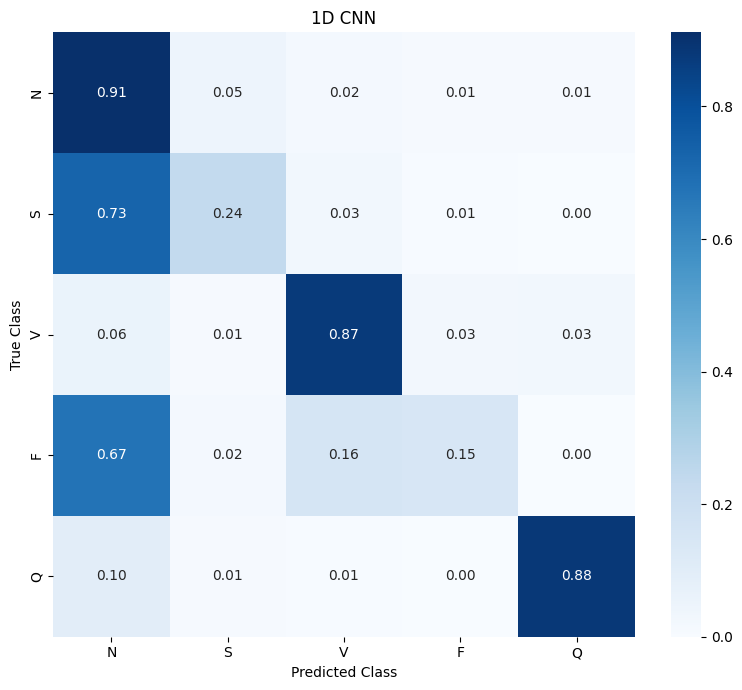

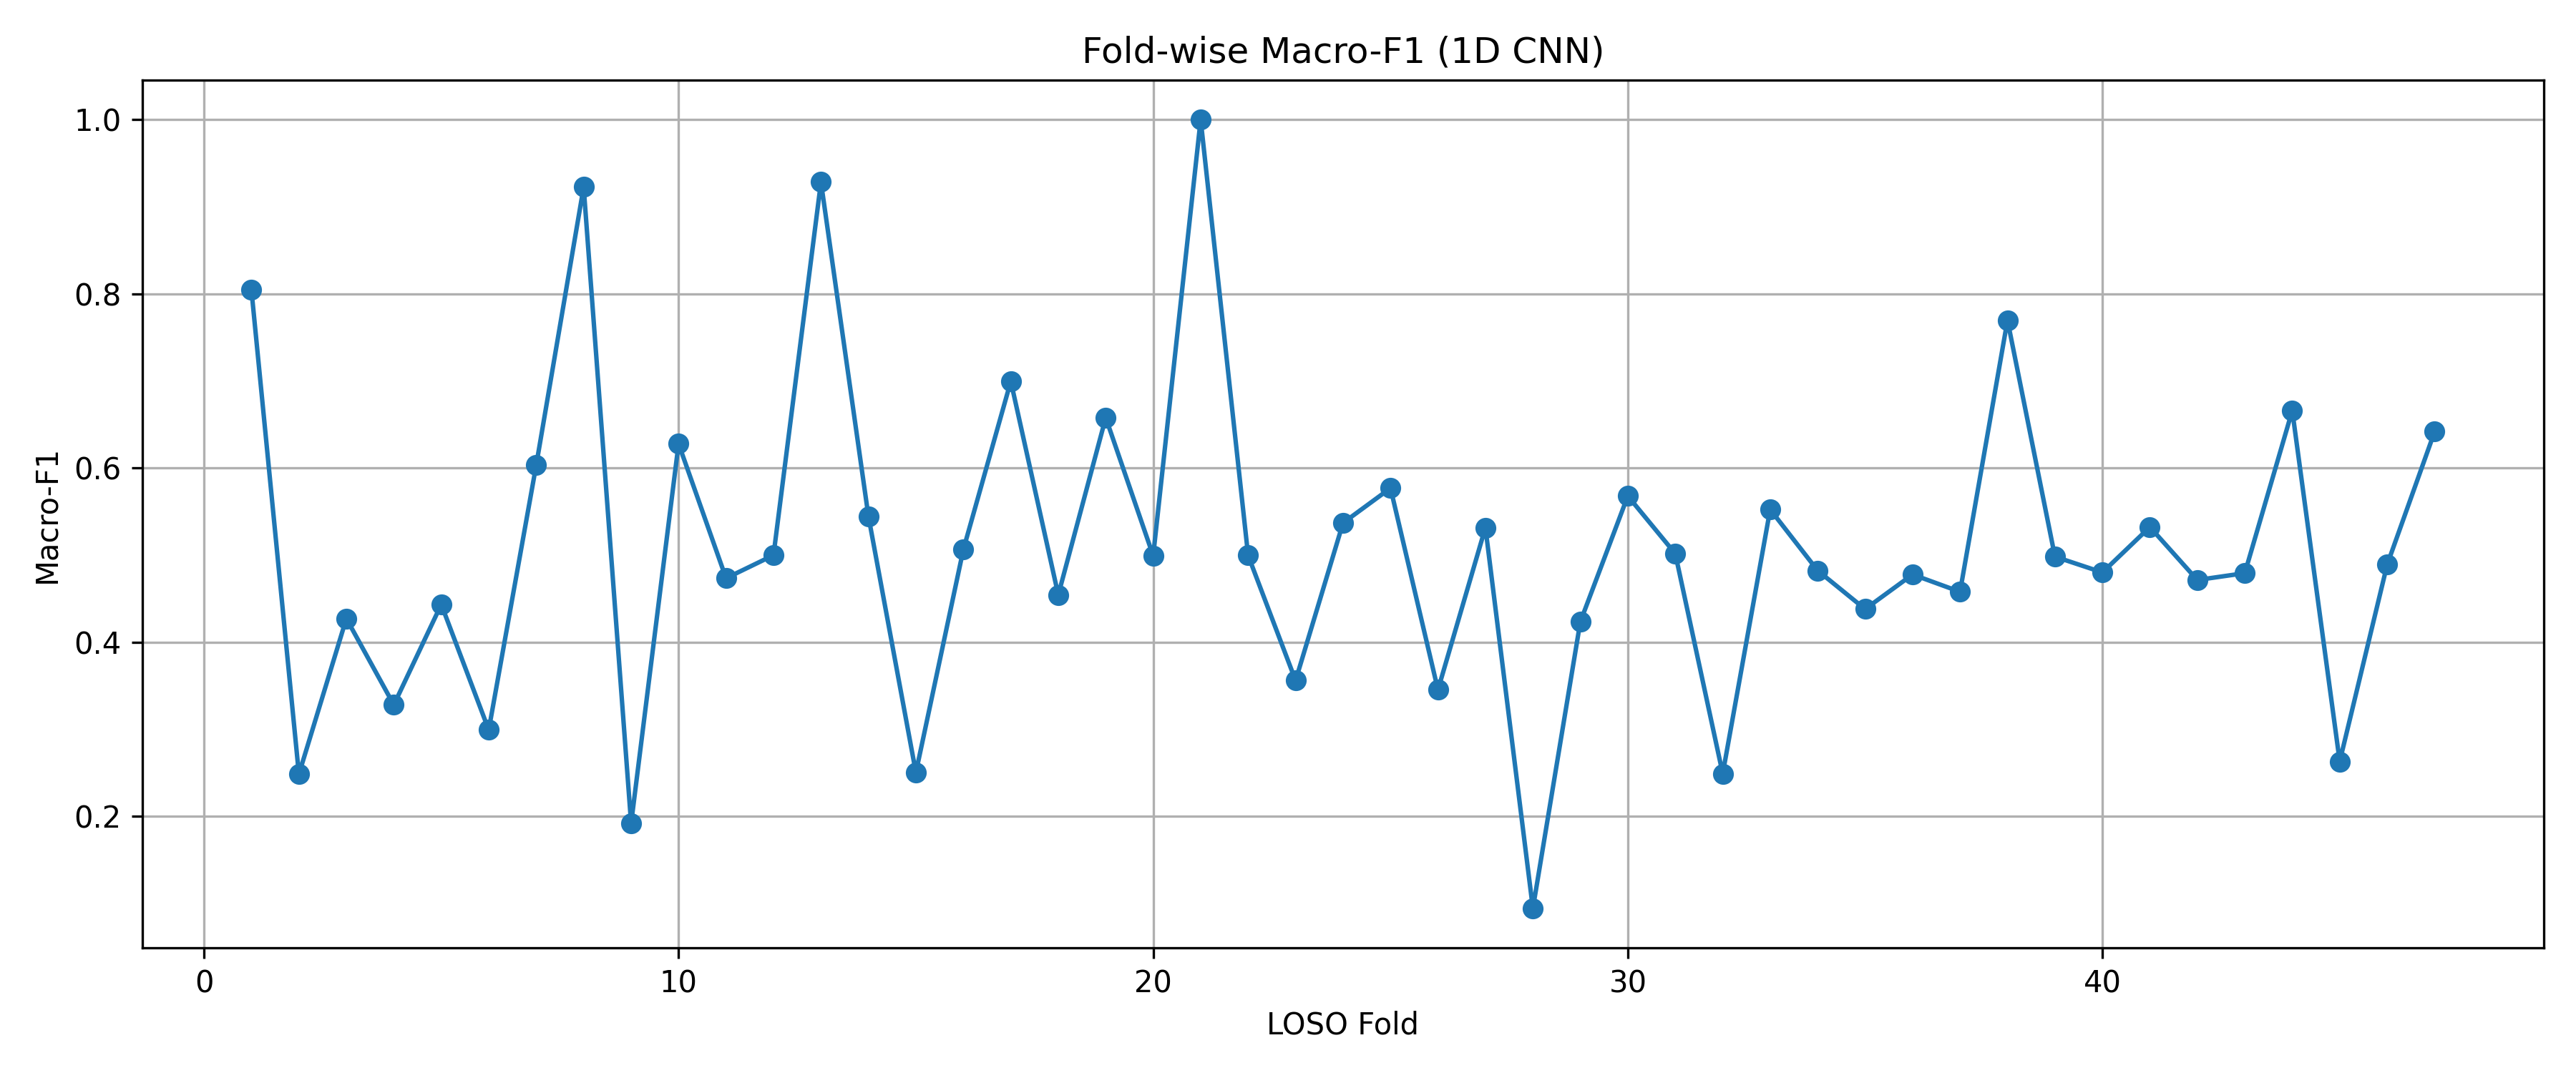

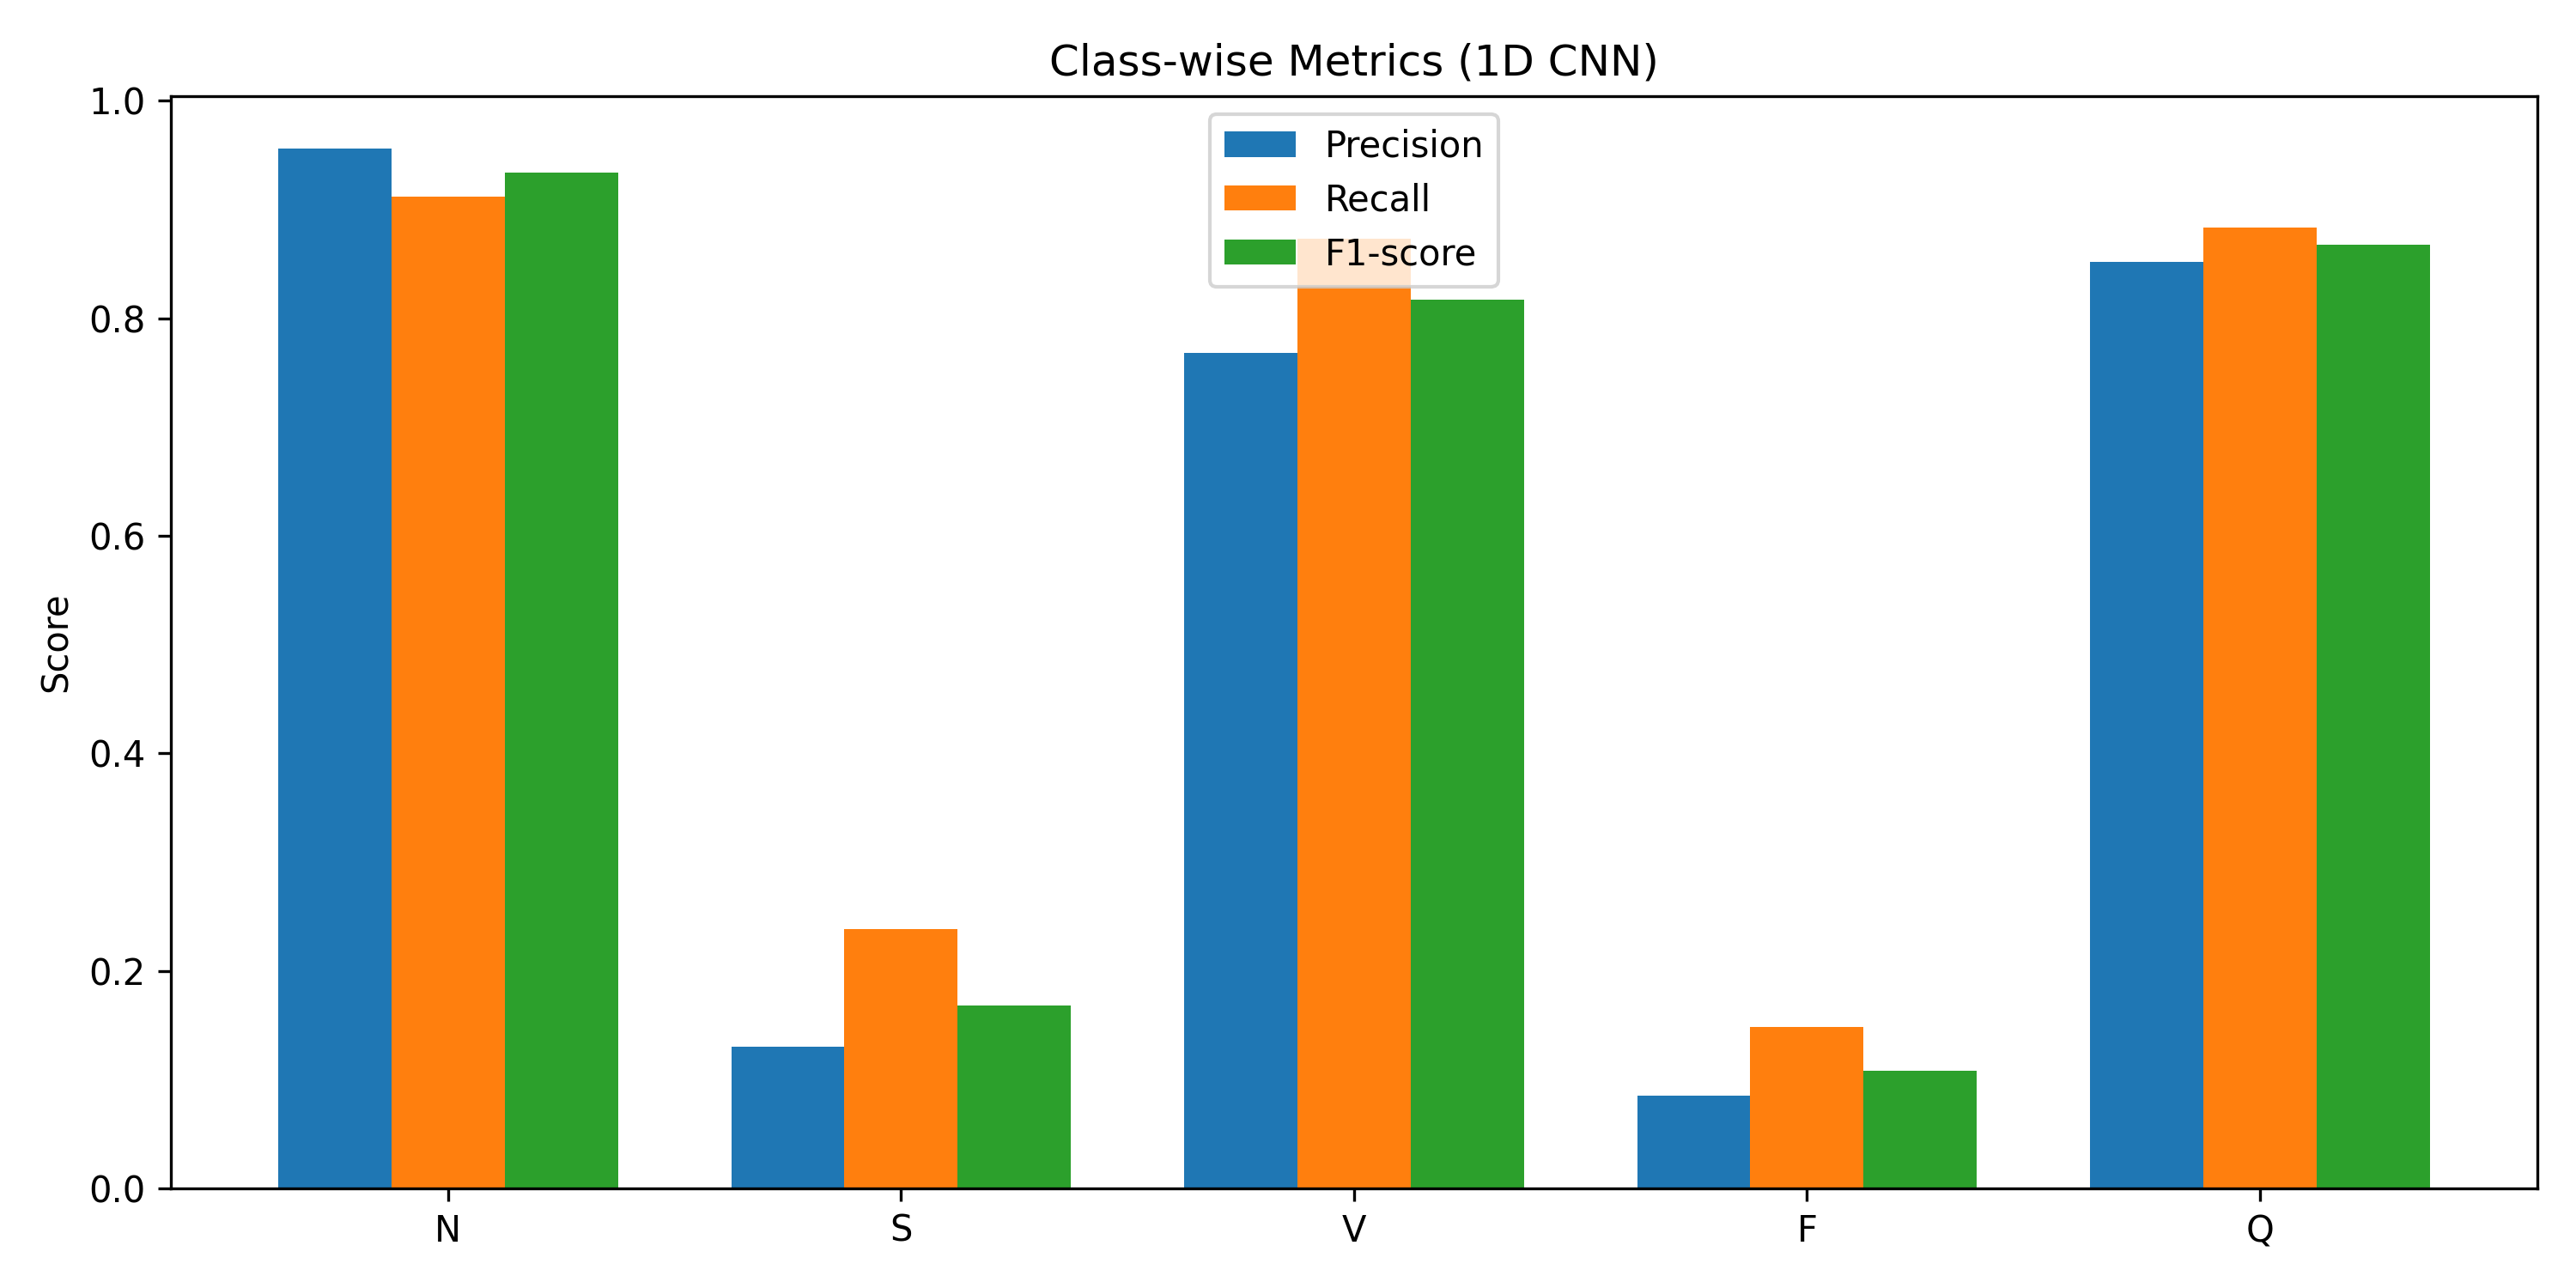

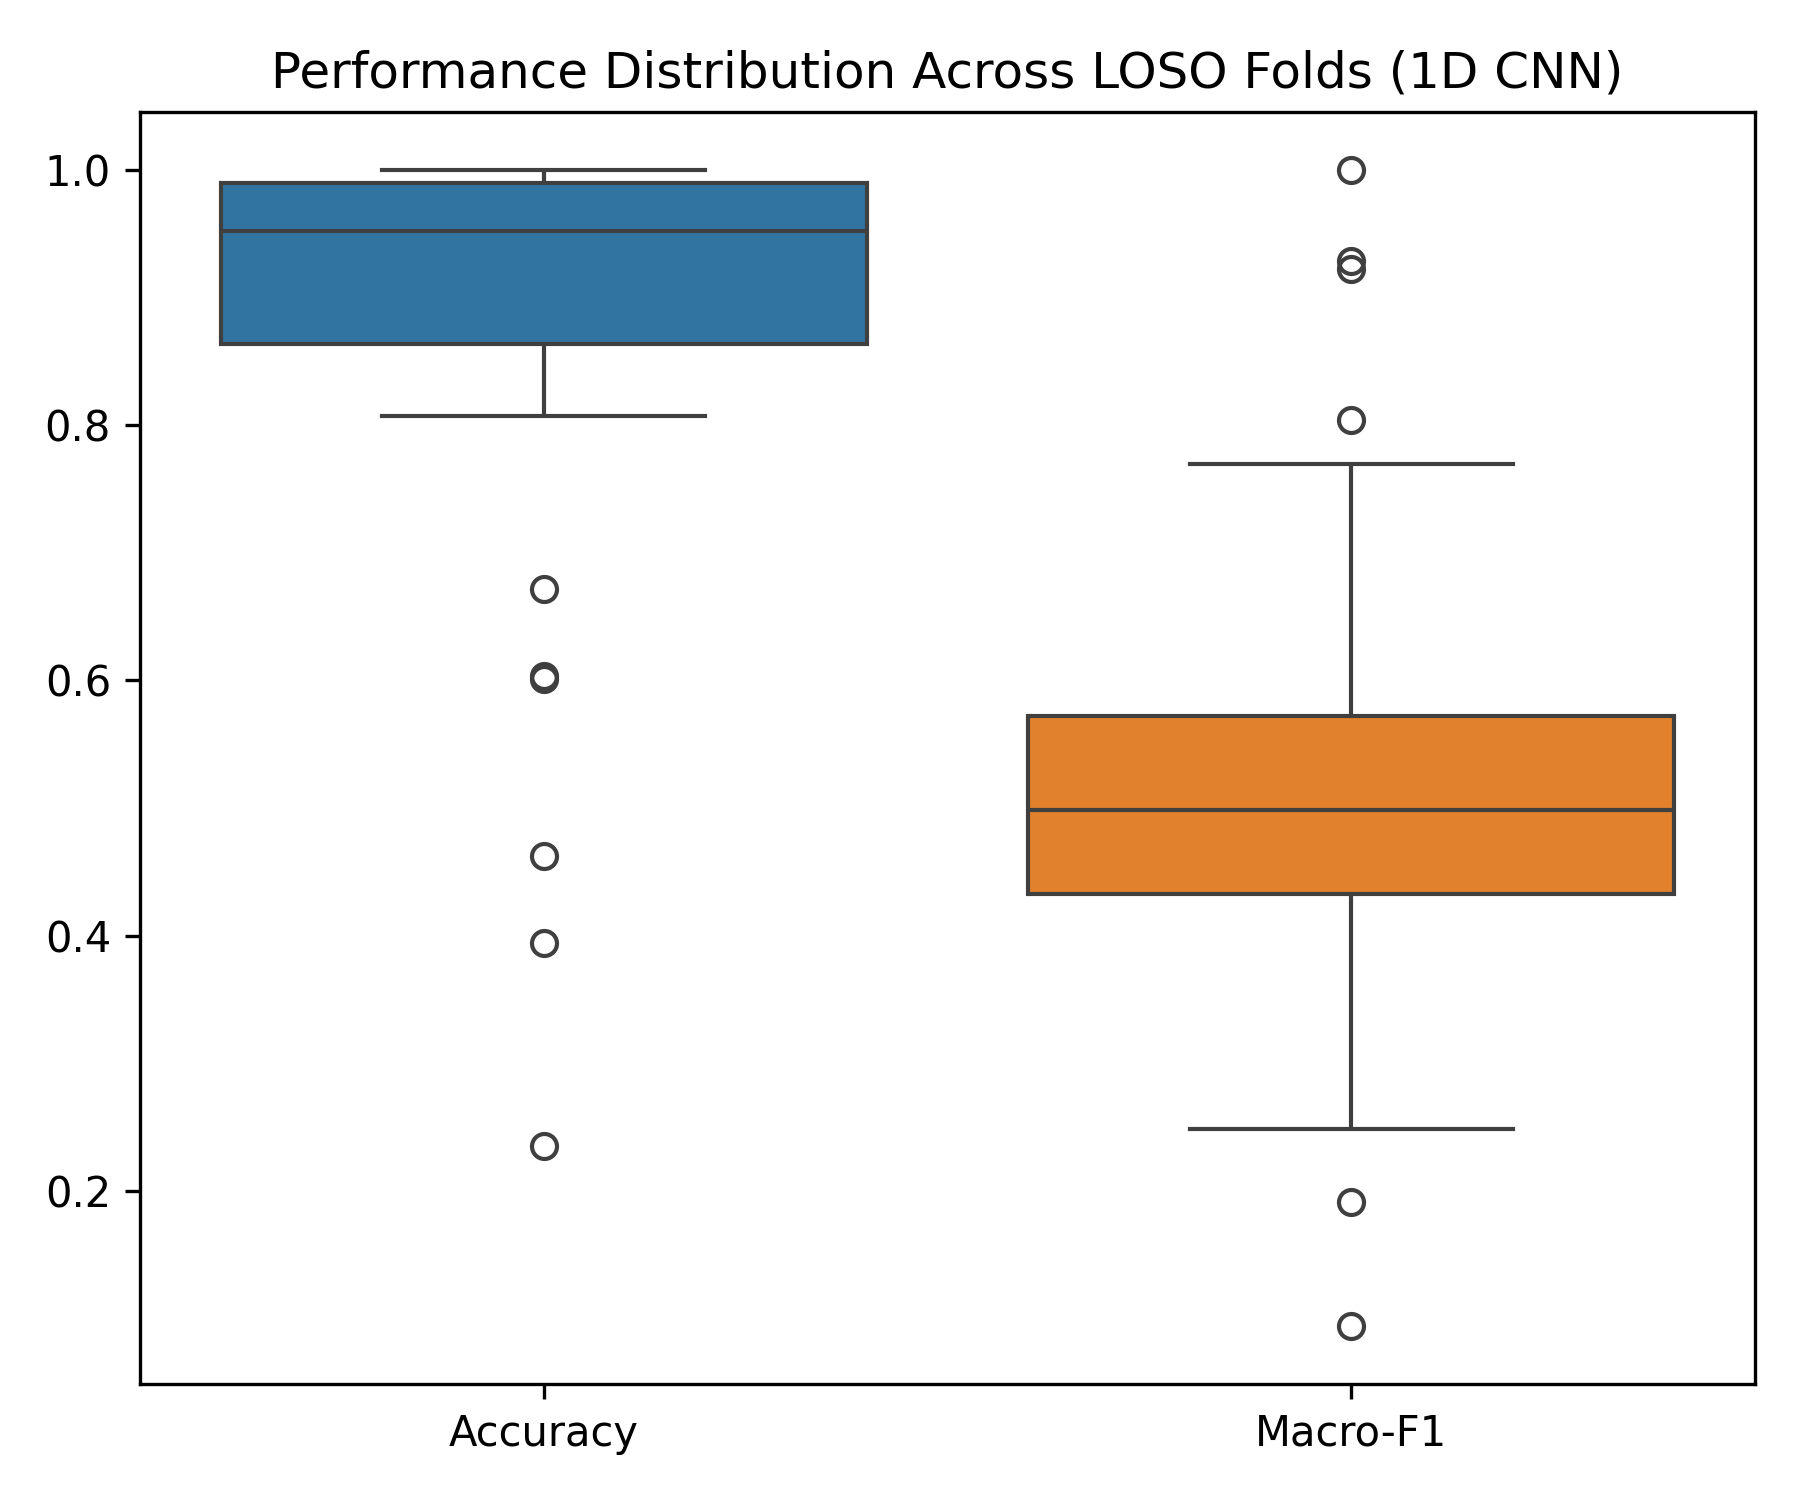

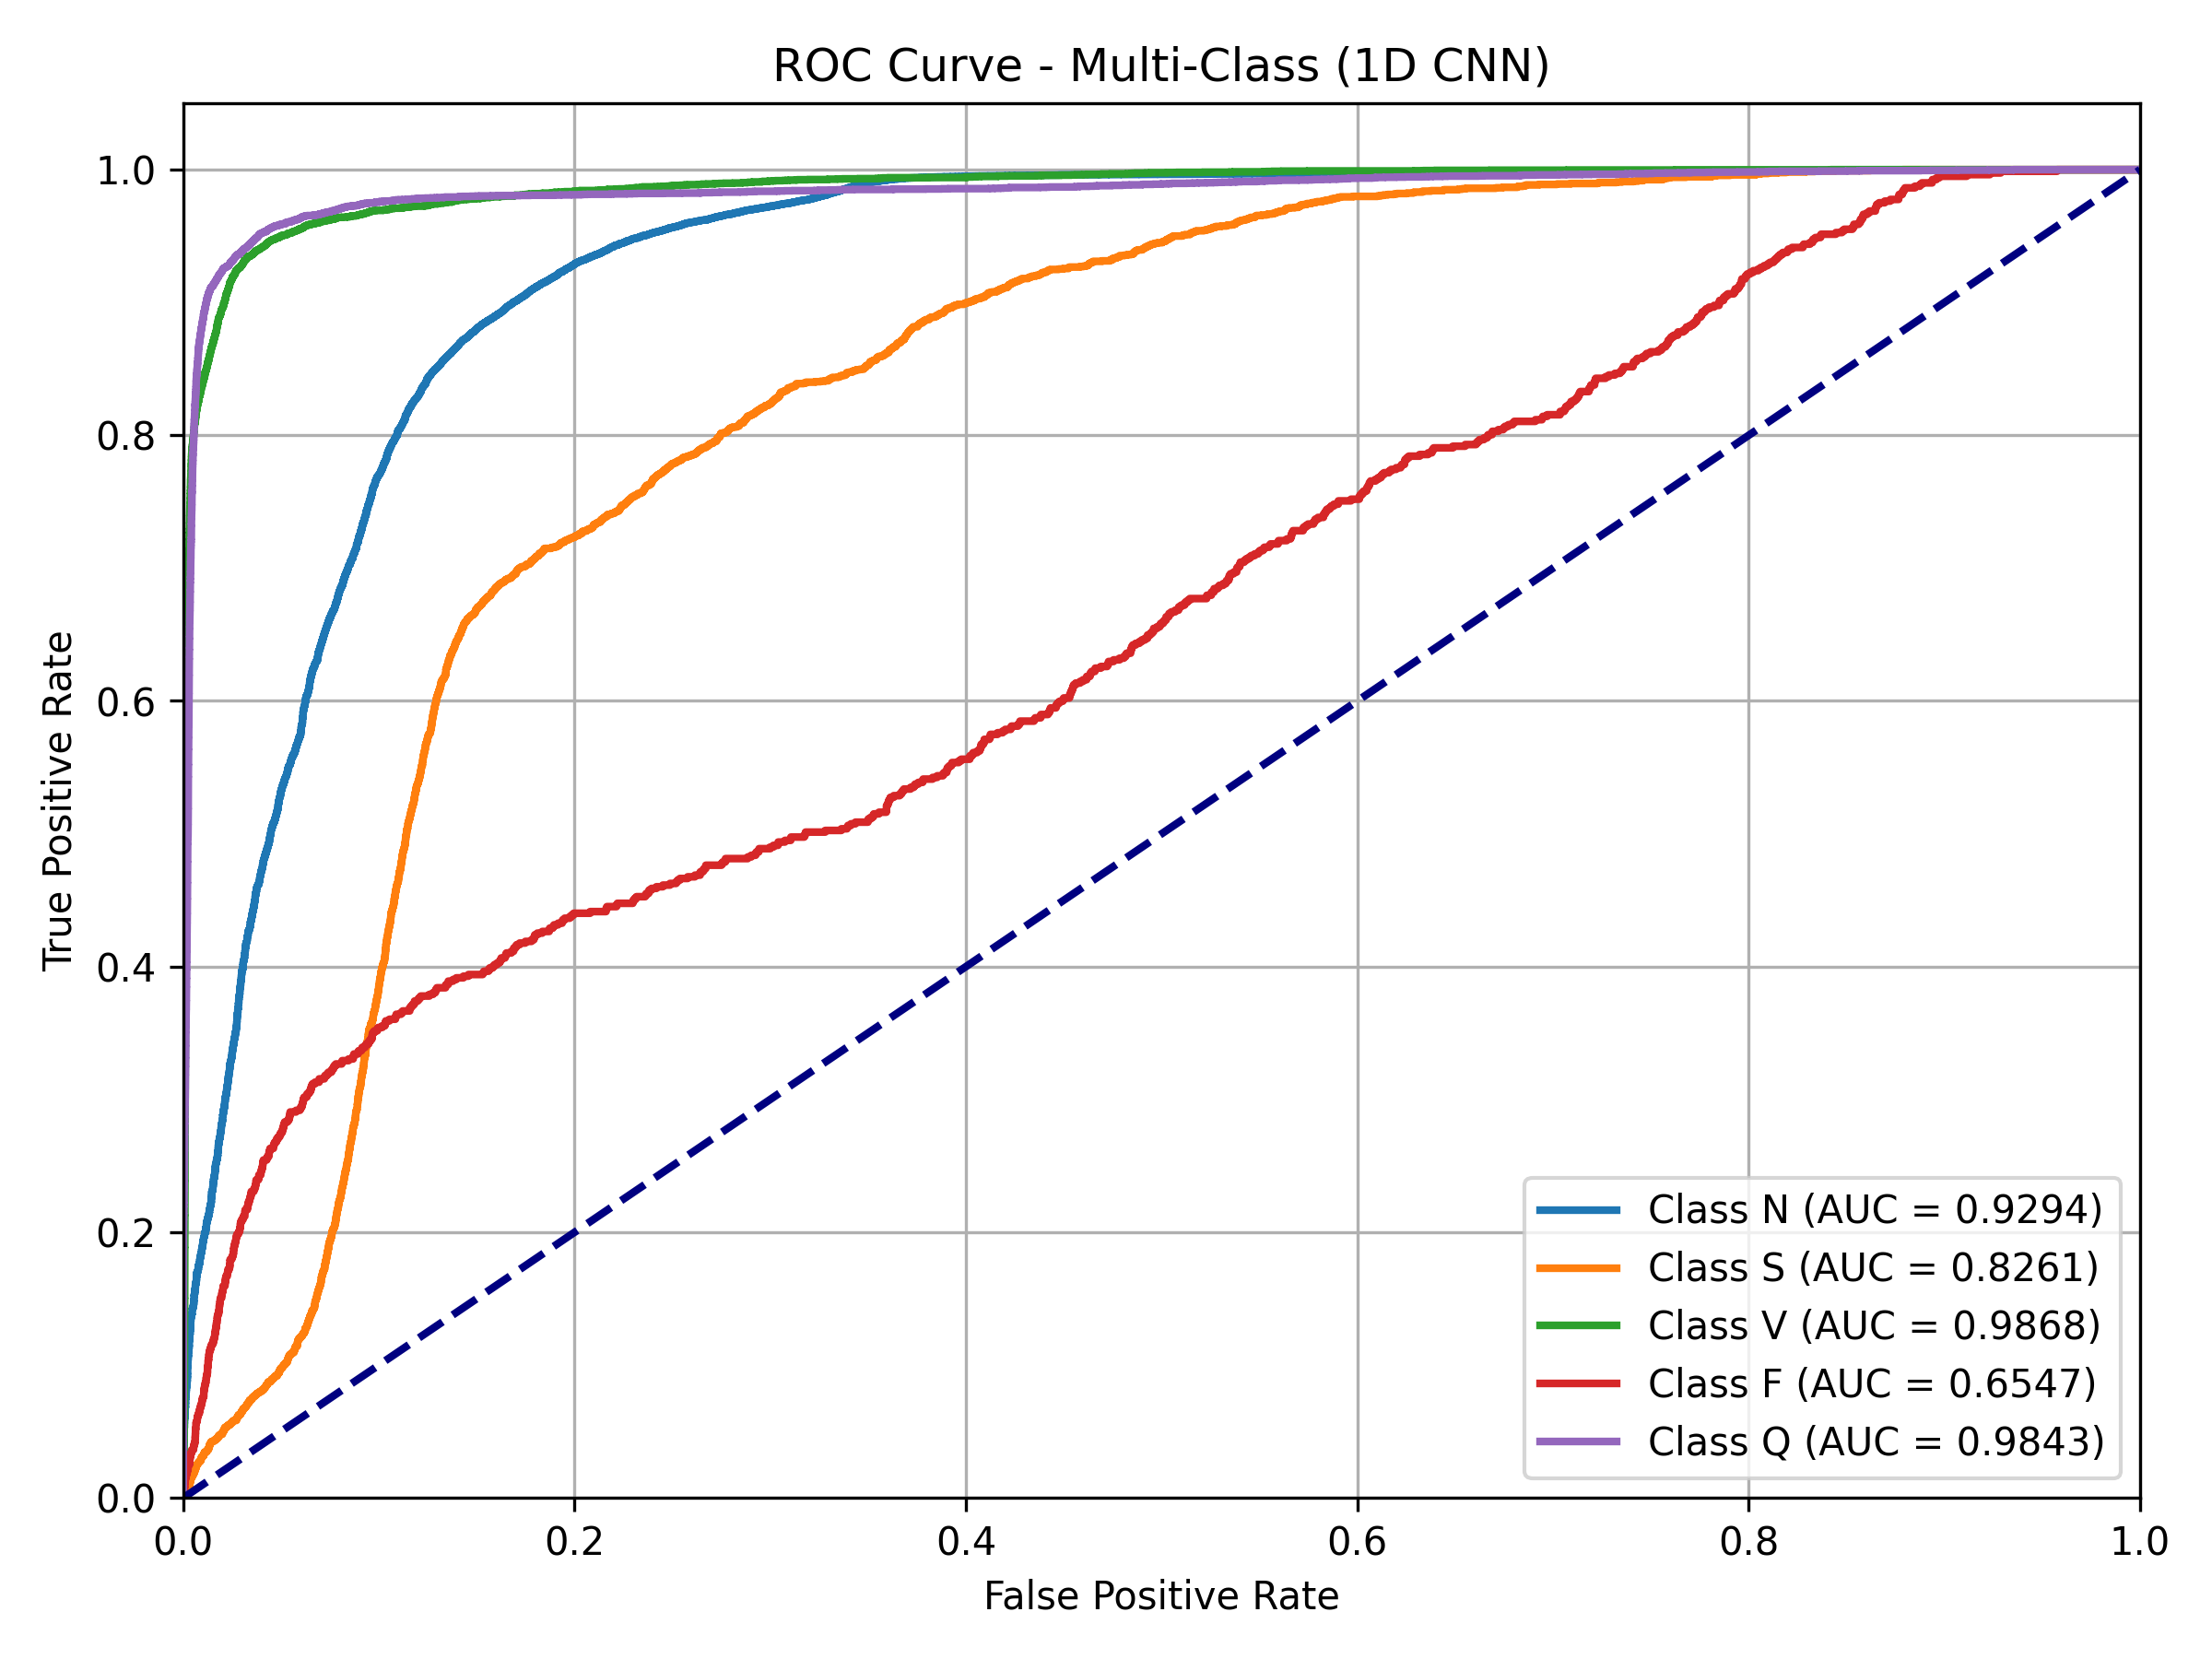

In [5]:
# Visualize_LOSO_Dual_Scale_CNN

import json
import pickle

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from IPython.display import Image, display

CLASS_NAMES = [
    "N",
    "S",
    "V",
    "F",
    "Q"
]

# =====================================================
# RESULT DIRECTORY
# Must match Step-08
# =====================================================

RESULTS_DIR = "results_dual_scale_cnn"

# =====================================================
# Load Results
# =====================================================

with open(
    f"{RESULTS_DIR}/loso_summary.json",
    "r"
) as f:

    summary = json.load(f)

with open(
    f"{RESULTS_DIR}/all_results.pkl",
    "rb"
) as f:

    all_results = pickle.load(f)

# =====================================================
# 1. Normalized Confusion Matrix
# =====================================================

cm = np.array(
    summary["aggregate_confusion_matrix"]
)

# Prevent division-by-zero if a class has no samples
row_sums = cm.sum(axis=1, keepdims=True)

cm_norm = np.divide(
    cm.astype(float),
    row_sums,
    out=np.zeros_like(cm, dtype=float),
    where=row_sums != 0
)

plt.figure(figsize=(8, 7))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title(
    "1D CNN"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.tight_layout()

plt.savefig(
    f"{RESULTS_DIR}/confusion_matrix_normalized.png",
    dpi=300
)

plt.close()

# =====================================================
# 2. Fold-wise Macro-F1
# =====================================================

folds = [
    r["fold"]
    for r in all_results
]

macro_f1 = [
    r["macro_f1"]
    for r in all_results
]

plt.figure(figsize=(12, 5))

plt.plot(
    folds,
    macro_f1,
    marker="o"
)

plt.title(
    "Fold-wise Macro-F1 (1D CNN)"
)

plt.xlabel(
    "LOSO Fold"
)

plt.ylabel(
    "Macro-F1"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{RESULTS_DIR}/fold_macro_f1.png",
    dpi=300
)

plt.close()

# =====================================================
# 3. Class-wise Precision Recall F1
# =====================================================

report = summary[
    "classification_report"
]

precision = [
    report[c]["precision"]
    for c in CLASS_NAMES
]

recall = [
    report[c]["recall"]
    for c in CLASS_NAMES
]

f1 = [
    report[c]["f1-score"]
    for c in CLASS_NAMES
]

x = np.arange(
    len(CLASS_NAMES)
)

width = 0.25

plt.figure(figsize=(10, 5))

plt.bar(
    x - width,
    precision,
    width,
    label="Precision"
)

plt.bar(
    x,
    recall,
    width,
    label="Recall"
)

plt.bar(
    x + width,
    f1,
    width,
    label="F1-score"
)

plt.xticks(
    x,
    CLASS_NAMES
)

plt.ylabel(
    "Score"
)

plt.title(
    "Class-wise Metrics (1D CNN)"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{RESULTS_DIR}/classwise_metrics.png",
    dpi=300
)

plt.close()

# =====================================================
# 4. Performance Boxplot
# =====================================================

accs = [
    r["accuracy"]
    for r in all_results
]

df = pd.DataFrame({
    "Accuracy": accs,
    "Macro-F1": macro_f1
})

plt.figure(figsize=(6, 5))

sns.boxplot(
    data=df
)

plt.title(
    "Performance Distribution Across LOSO Folds (1D CNN)"
)

plt.tight_layout()

plt.savefig(
    f"{RESULTS_DIR}/performance_boxplot.png",
    dpi=300
)

plt.close()

# =====================================================
# 5. Multi-Class ROC Curve (One-vs-Rest)
# =====================================================

all_labels = np.concatenate([
    np.asarray(r["labels"])
    for r in all_results
])

all_logits = np.concatenate([
    np.asarray(r["logits"])
    for r in all_results
])

n_classes = len(CLASS_NAMES)

y_bin = label_binarize(
    all_labels,
    classes=range(n_classes)
)

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(CLASS_NAMES):

    fpr, tpr, _ = roc_curve(
        y_bin[:, i],
        all_logits[:, i]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"Class {class_name} (AUC = {roc_auc:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    color="navy",
    lw=2,
    linestyle="--"
)

plt.xlim(
    [0.0, 1.0]
)

plt.ylim(
    [0.0, 1.05]
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve - Multi-Class (1D CNN)"
)

plt.legend(
    loc="lower right"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{RESULTS_DIR}/roc_curves.png",
    dpi=300
)

plt.close()

# =====================================================
# Generated Figures
# =====================================================

print(
    "\nGenerated Figures:"
)

print("confusion_matrix_normalized.png")
print("fold_macro_f1.png")
print("classwise_metrics.png")
print("performance_boxplot.png")
print("roc_curves.png")

# =====================================================
# Inline Notebook Rendering
# =====================================================

plt.figure(figsize=(8, 7))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title(
    "1D CNN"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.tight_layout()

plt.show()

display(
    Image(
        f"{RESULTS_DIR}/fold_macro_f1.png"
    )
)

display(
    Image(
        f"{RESULTS_DIR}/classwise_metrics.png"
    )
)

display(
    Image(
        f"{RESULTS_DIR}/performance_boxplot.png"
    )
)

display(
    Image(
        f"{RESULTS_DIR}/roc_curves.png"
    )
)